In [354]:
#Import dependencies

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Load Data


In [355]:


data_add = "../data/MarketingData.xlsx"

df = pd.read_excel(data_add)




# Phase 1 - Understand the Dataset

The first step in exploratory data analysis (EDA) is to understand the structure and contents of the dataset before performing any cleaning or statistical analysis.

## Objective

The objective of this phase is to:

- Understand what each observation (row) represents.
- Identify the variables (columns) available for analysis.
- Determine the data type of each variable.
- Gain a general understanding of the dataset's structure.

---

## Observation Unit

Each row in the dataset represents the performance of **one advertising campaign** on a specific:

- Date
- Advertising platform
- Geographic region

The dataset contains performance metrics such as advertising spend, impressions, clicks, purchases, revenue, and customer lifetime value (LTV).





In [356]:
df

,Date,Platform,Campaign,Region,Spend,CPM,Impressions,Frequency,Clicks,Purchases,Revenue,Product_Category,Target_Audience,Creative_Type,Video_Completion_Rate,Customer_LTV,Is_Competitive_Event
0,2024-01-01,FB,FB_Athletes_Video_Protein_001,West,1187.29,18.00,65960,2.75,527,15,1216.74,Protein,Athletes,Video,0.4860,772.80,True
1,2024-01-01,FB,FB_Athletes_Video_Protein_001,South,1081.89,18.00,60105,2.51,512,12,868.16,Protein,Athletes,Video,0.4860,772.80,True
2,2024-01-01,FB,FB_Athletes_Video_Protein_001,Northeast,648.47,18.00,36025,2.52,344,9,694.68,Protein,Athletes,Video,0.4860,772.80,True
3,2024-01-01,FB,FB_Athletes_Video_Protein_001,Midwest,463.38,18.00,25743,2.49,272,6,482.66,Protein,Athletes,Video,0.4860,772.80,True
4,2024-01-01,FB,FB_Athletes_Image_Preworkout_002,West,800.59,18.00,44477,3.10,418,14,852.22,Preworkout,Athletes,Image,NaN,538.20,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3235,2024-03-30,TT,TT_FitnessEnth_Video_Preworkout_001,Midwest,1210.98,15.03,80580,2.25,357,8,475.93,Preworkout,FitnessEnth,Video,NaN,351.00,False
3236,2024-03-30,TT,TT_WeightLoss_Video_Diet_001,West,1393.13,15.03,92701,2.89,334,8,491.48,Diet,WeightLoss,Video,0.5076,252.72,False
3237,2024-03-30,TT,TT_WeightLoss_Video_Diet_001,South,1879.82,15.03,125086,2.42,517,12,665.84,Diet,WeightLoss,Video,0.5076,252.72,False
3238,2024-03-30,TT,TT_WeightLoss_Video_Diet_001,Northeast,2312.32,15.03,153865,3.67,614,18,1067.11,Diet,WeightLoss,Video,0.5076,252.72,False


This dataset contains 3 month long data from **January 1, 2024 - March 3, 2024**.

In [357]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   3240 non-null   datetime64[ns]
 1   Platform               3240 non-null   object        
 2   Campaign               3240 non-null   object        
 3   Region                 3240 non-null   object        
 4   Spend                  3240 non-null   float64       
 5   CPM                    3240 non-null   float64       
 6   Impressions            3240 non-null   int64         
 7   Frequency              3240 non-null   float64       
 8   Clicks                 3240 non-null   int64         
 9   Purchases              3240 non-null   int64         
 10  Revenue                3220 non-null   float64       
 11  Product_Category       3240 non-null   object        
 12  Target_Audience        3240 non-null   object        
 13  Cre

---

## Variables

| Variable | Description | Type |
|-----------|-------------|------|
| Date | Date when campaign metrics were recorded | Date |
| Platform | Advertising platform (e.g., Facebook, Google) | Categorical |
| Campaign | Name of the advertising campaign | Categorical |
| Region | Geographic region | Categorical |
| Spend | Advertising cost | Continuous |
| CPM | Cost per 1,000 impressions | Continuous |
| Impressions | Number of ad impressions | Count |
| Frequency | Average number of times a user saw the ad | Continuous |
| Clicks | Number of ad clicks | Count |
| Purchases | Number of purchases attributed to the campaign | Count |
| Revenue | Revenue generated by the campaign | Continuous |
| Video_Completion_Rate | Percentage of users who completed the video advertisement | Continuous |
| Customer_LTV | Average customer lifetime value | Continuous |
| Product_Category | Product category being advertised | Categorical |
| Target_Audience | Intended audience segment | Categorical |

---

## Initial Observations

At this stage, no conclusions are drawn about the quality of the data.

The goal is simply to become familiar with:

- The available variables.
- The meaning of each variable.
- The types of data contained in the dataset.

The next phase focuses on assessing data quality by checking for missing values, duplicates, incorrect data types, and logical inconsistencies.

# Phase 2 - Data Quality Assessment


## Missing Values

### 1. video_completion_rate

There seems to be lots of missing data on the `video_completion_rate` column(around 62% missing values!).

The question is, are the missing values **random** or **systematic**? To answer this, we investigate.

In [358]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   3240 non-null   datetime64[ns]
 1   Platform               3240 non-null   object        
 2   Campaign               3240 non-null   object        
 3   Region                 3240 non-null   object        
 4   Spend                  3240 non-null   float64       
 5   CPM                    3240 non-null   float64       
 6   Impressions            3240 non-null   int64         
 7   Frequency              3240 non-null   float64       
 8   Clicks                 3240 non-null   int64         
 9   Purchases              3240 non-null   int64         
 10  Revenue                3220 non-null   float64       
 11  Product_Category       3240 non-null   object        
 12  Target_Audience        3240 non-null   object        
 13  Cre

After careful analysis, I realized that the `video_completion_rate` column is only relevant to rows with video as the `creative_type`. So when we filter it out...

There are only around **212** missing values!

In [359]:
df_video_type = df[df['Creative_Type'] == 'Video']

df_video_type.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1440 entries, 0 to 3239
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   1440 non-null   datetime64[ns]
 1   Platform               1440 non-null   object        
 2   Campaign               1440 non-null   object        
 3   Region                 1440 non-null   object        
 4   Spend                  1440 non-null   float64       
 5   CPM                    1440 non-null   float64       
 6   Impressions            1440 non-null   int64         
 7   Frequency              1440 non-null   float64       
 8   Clicks                 1440 non-null   int64         
 9   Purchases              1440 non-null   int64         
 10  Revenue                1434 non-null   float64       
 11  Product_Category       1440 non-null   object        
 12  Target_Audience        1440 non-null   object        
 13  Creative



At this stage, the exact cause is unknown and may require further investigation if this variable becomes important in the analysis.

The missing values occur only in the `Video_Completion_Rate` column, while the remaining campaign information is complete. Therefore, removing these rows would result in the unnecessary loss of valuable observations.

For this reason, the rows will be retained in the dataset. Instead, analyses involving `Video_Completion_Rate` will use only the subset of observations where this metric is available. This approach preserves the maximum amount of information while ensuring calculations involving `Video_Completion_Rate` are based only on valid data.

### 2. Revenue

 There seems to be some missing values for the `Revenue` column as well. This column is very important as it is used as the basis for the KPI metrics like ROAS, CPA, etc..


In [360]:
df[df['Revenue'].isna()].head()

,Date,Platform,Campaign,Region,Spend,CPM,Impressions,Frequency,Clicks,Purchases,Revenue,Product_Category,Target_Audience,Creative_Type,Video_Completion_Rate,Customer_LTV,Is_Competitive_Event
194,2024-01-06,Google,Google_Athletes_Search_Protein_001,Northeast,1225.52,18.09,67745,2.27,1236,35,NaN,Protein,Athletes,Search,NaN,940.8,False
589,2024-01-17,Google,Google_Athletes_Search_Protein_001,South,978.48,15.24,64204,2.03,979,32,NaN,Protein,Athletes,Search,NaN,940.8,False
1413,2024-02-09,FB,FB_FitnessEnth_Carousel_WeightLoss_001,South,1909.27,12.47,153133,3.61,823,24,NaN,WeightLoss,FitnessEnth,Carousel,NaN,448.5,False
1658,2024-02-16,FB,FB_Athletes_Video_Protein_001,Northeast,974.65,12.55,77649,2.08,505,16,NaN,Protein,Athletes,Video,0.4413,772.8,False
1661,2024-02-16,FB,FB_Athletes_Image_Preworkout_002,South,913.94,12.55,72812,4.25,243,6,NaN,Preworkout,Athletes,Image,NaN,538.2,False


The `Revenue` column contains **20 missing values**, representing approximately **0.6%** of the dataset.

A manual inspection of these observations did not reveal any obvious systematic pattern (e.g., a specific platform, campaign, region, or date associated with the missing values). Therefore, the missingness appears to be random rather than concentrated within a particular subset of the data.

Because the proportion of missing values is very small, removing these observations is unlikely to introduce significant bias or substantially reduce the available information. Consequently, these rows will be removed from the dataset for analyses involving the `Revenue` variable.

In [361]:
print("BEFORE DROPPING: Number of rows with missing revenue:",len(df[df['Revenue'].isna()]))

df.dropna(subset=["Revenue"], inplace=True)

print("AFTER DROPPING: Number of rows with missing revenue:",len(df[df['Revenue'].isna()]))

BEFORE DROPPING: Number of rows with missing revenue: 20
AFTER DROPPING: Number of rows with missing revenue: 0


## Duplicated Rows

We checked for duplicated rows and found nothing.

In [362]:
print("Number of duplicated rows: ", df.duplicated().sum(), "rows")

Number of duplicated rows:  0 rows


## Data Inconsistencies

### 1. Clicks

I noticed that there are rows with 0 clicks but has non-zero `Purchases`, which was weird. 

So, we also investigated that here


In [363]:
df[(df['Clicks'] == 0)]

,Date,Platform,Campaign,Region,Spend,CPM,Impressions,Frequency,Clicks,Purchases,Revenue,Product_Category,Target_Audience,Creative_Type,Video_Completion_Rate,Customer_LTV,Is_Competitive_Event
51,2024-01-02,Google,Google_Athletes_Search_Protein_001,Midwest,1045.31,15.01,0,3.09,0,0,2021.74,Protein,Athletes,Search,NaN,940.8,False
86,2024-01-03,Google,Google_Athletes_Search_Protein_001,Northeast,1303.24,15.03,86709,2.61,0,41,3593.14,Protein,Athletes,Search,NaN,940.8,False
92,2024-01-03,Google,Google_FitnessEnth_Display_Preworkout_001,West,469.88,15.03,31262,2.57,0,13,715.20,Preworkout,FitnessEnth,Display,NaN,546.0,False
94,2024-01-03,Google,Google_FitnessEnth_Display_Preworkout_001,Northeast,921.64,15.03,61320,3.77,0,12,691.31,Preworkout,FitnessEnth,Display,NaN,546.0,False
122,2024-01-04,Google,Google_Athletes_Search_Protein_001,Northeast,642.88,15.04,42730,3.42,0,16,1388.57,Protein,Athletes,Search,NaN,940.8,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3047,2024-03-25,Google,Google_FitnessEnth_Display_Preworkout_001,Midwest,988.78,16.26,60810,3.28,0,5,307.60,Preworkout,FitnessEnth,Display,NaN,546.0,False
3075,2024-03-26,Google,Google_Athletes_Search_Protein_001,Midwest,950.82,18.72,50802,2.51,0,7,562.38,Protein,Athletes,Search,NaN,940.8,False
3109,2024-03-27,Google,Google_Athletes_Search_Protein_001,South,1181.40,18.73,63063,2.41,0,8,652.57,Protein,Athletes,Search,NaN,940.8,False
3145,2024-03-28,Google,Google_Athletes_Search_Protein_001,South,671.85,18.75,35830,2.55,0,6,521.90,Protein,Athletes,Search,NaN,940.8,False


Apparently, this happens in real world scenarios and they are called **view-through conversions**. People see the ad, they don't click it then later that evening, they remembered the brand and typed the website into google and bought the product.(I learned something new here, thank you internet).

But, at this point, I was wondering how they know which ad actually influenced the purchased without click or what if the buyer interacted with multiple ads before purchasing(cross-channel conversions). Apparently, this is related to attribution, and there are multiple attribution models like **last_click attribution**, **first-click attribution**, **linear_attribution**, etc.. which is not part of this data cleaning process. 

So, for now, I'll just assume that this dataset was collected using a certain attribution model and leave it at that. This justifies the 0 clicks with non-zero purchase.

### 2. Cost Per Mille (CPM)

**Cost Per Mille (CPM)** measures the **cost of 1,000 ad impressions**. It is commonly used to evaluate the cost efficiency of awareness and branding campaigns.

### Equation

$$
\boxed{\text{CPM} = \frac{\text{Spend}}{\text{Impressions}} \times 1000}
$$

where:

- **Spend** = Total advertising cost
- **Impressions** = Number of times the advertisement was shown

### Interpretation

- **Lower CPM** → More cost-efficient at generating impressions.
- **Higher CPM** → More expensive to reach the same audience.

---



### There were rows with Impressions = 0

Since impressions appear in the denominator,

$$
\text{CPM}=\frac{\text{Spend}}{0}\times1000
$$

the value is **undefined** because division by zero is not possible.


## Summary

| Condition | CPM |
|-----------|-----|
| Impressions > 0 | Can be computed normally |
| Impressions = 0 | Undefined (NaN) |


However, when you look at our data, we noticed some inconsistencies. There seems to be a total of 47 rows where `Impressions` is 0 but `CPM` is non-zero. In addition, all of them seems to come from the **Midwest region**. So, it seems to be a **systematic error**.

This imples that the midwest reporting pipeline might have failed for traffic metrics. These 47(1.45% of our total data) rows are incosistent and may affect our calculations of other KPIs like CTR and Conversion Rate. 

Thus, I decided to drop them from the dataset.

In [364]:
mask = (
    (df["Impressions"] == 0) &
    (df['CPM'] > 0) 

)

df[mask].head()



,Date,Platform,Campaign,Region,Spend,CPM,Impressions,Frequency,Clicks,Purchases,Revenue,Product_Category,Target_Audience,Creative_Type,Video_Completion_Rate,Customer_LTV,Is_Competitive_Event
51,2024-01-02,Google,Google_Athletes_Search_Protein_001,Midwest,1045.31,15.01,0,3.09,0,0,2021.74,Protein,Athletes,Search,NaN,940.80,False
199,2024-01-06,Google,Google_WeightLoss_Search_Diet_001,Midwest,1067.90,18.09,0,4.16,0,0,1542.29,Diet,WeightLoss,Search,NaN,393.12,False
251,2024-01-07,TT,TT_WeightLoss_Video_Diet_001,Midwest,2619.73,12.07,0,2.11,0,0,3362.89,Diet,WeightLoss,Video,0.6101,252.72,False
259,2024-01-08,FB,FB_Athletes_Image_Preworkout_002,Midwest,745.96,12.08,0,2.83,0,0,527.76,Preworkout,Athletes,Image,NaN,538.20,False
311,2024-01-09,Google,Google_FitnessEnth_Display_Preworkout_001,Midwest,616.90,15.12,0,2.42,0,0,518.51,Preworkout,FitnessEnth,Display,NaN,546.00,False


In [365]:
df["CPM_calc"] = df["Spend"] / df["Impressions"] * 1000

mask = ~np.isclose(df["CPM"], df["CPM_calc"], rtol=1e-3)

print(mask.sum())

52


In [366]:
mask = (df["Impressions"] == 0) & (df["CPM"] > 0)

print("Rows before removal:", mask.sum())

df.drop(df[mask].index, inplace=True)

mask = (df["Impressions"] == 0) & (df["CPM"] > 0)
print("Rows after removal:", mask.sum())

Rows before removal: 47
Rows after removal: 0


# Phase 3 - Which performance metrics show the most concerning trends?



## Performance Metric Calculation
Below is a code that summarizes the 3 month long advertising campaign dataset into a dataframe.

In [367]:
import numpy as np

campaign_summary = (
    df.groupby("Campaign")
      .agg({
          "Spend": "sum",
          "Revenue": "sum",
          "Clicks": "sum",
          "Purchases": "sum",
          "Impressions": "sum",
          "Frequency": "mean",
          "Customer_LTV": "mean",
          "Is_Competitive_Event": "mean"
      })
)

# Calculate campaign-level performance metrics
campaign_summary["CTR"] = np.where(
    campaign_summary["Impressions"] > 0,
    (campaign_summary["Clicks"] / campaign_summary["Impressions"]) * 100,
    np.nan
)

campaign_summary["CPC"] = np.where(
    campaign_summary["Clicks"] > 0,
    campaign_summary["Spend"] / campaign_summary["Clicks"],
    np.nan
)

campaign_summary["CVR"] = np.where(
    campaign_summary["Clicks"] > 0,
    (campaign_summary["Purchases"] / campaign_summary["Clicks"]) * 100,
    np.nan
)

campaign_summary["ROAS"] = np.where(
    campaign_summary["Spend"] > 0,
    campaign_summary["Revenue"] / campaign_summary["Spend"],
    np.nan
)

campaign_summary.rename(
    columns={"Is_Competitive_Event": "Competitive_Event_%"},
    inplace=True
)

campaign_summary["Competitive_Event_%"] *= 100

In [368]:
campaign_summary

,Spend,Revenue,Clicks,Purchases,Impressions,Frequency,Customer_LTV,Competitive_Event_%,CTR,CPC,CVR,ROAS
Campaign,,,,,,,,,,,,
FB_Athletes_Image_Preworkout_002,375440.11,224417.39,141148,3736,27078954,2.957163,538.20,4.584527,0.521246,2.659904,2.646867,0.597745
FB_Athletes_Video_Protein_001,397009.01,414611.32,176101,5192,28769697,3.024800,772.80,4.285714,0.612106,2.254439,2.948308,1.044337
FB_FitnessEnth_Carousel_WeightLoss_001,658034.39,444386.43,231088,7378,42127774,3.023662,448.50,4.507042,0.548541,2.847549,3.192723,0.675324
Google_Athletes_Search_Protein_001,451774.14,525003.97,198738,6565,20805382,2.995629,940.80,4.571429,0.955224,2.273215,3.303344,1.162094
Google_FitnessEnth_Display_Preworkout_001,509339.68,223464.16,188131,3729,20034776,2.960057,546.00,4.310345,0.939022,2.707367,1.982129,0.438733
Google_WeightLoss_Search_Diet_001,524368.42,616216.13,325983,10207,30858988,3.005718,393.12,4.507042,1.056363,1.608576,3.131145,1.175159
TT_Athletes_Video_Protein_001,622385.81,659937.43,273028,8254,44267035,3.089718,604.80,4.519774,0.616775,2.279568,3.023133,1.060335
TT_FitnessEnth_Video_Preworkout_001,493798.77,289098.57,263964,4825,43427853,2.984270,351.00,4.494382,0.607822,1.870705,1.827901,0.585458
TT_WeightLoss_Video_Diet_001,738967.18,736116.27,421061,12256,65081230,3.048315,252.72,4.494382,0.646978,1.755012,2.910742,0.996142



## Observations


**Case 1: High CTR + Low CVR**

 - CTR varies considerably across campaigns, suggesting differences in audience engagement.
 - Specifically, I see the **Google_FitnessEnth_Display_Preworkout_001** campaign has high CTR but low CVR which implies something that the ad is interesting, it get clicks, but somehow after clicking, something went wrong leading to low CVR and correspondingly low ROAS.

**Possible areas to investigate**
 - landing page quality
 - page speed
 - confusing checkout
 - incorrect audience targeting
 - lack of trust signals
 .
 .
 .


**Case 2: Low CTR + average CVR**

 - Certain campaigns has low CTR but average CVR.
 - Maybe we could further increase or optimize ROAS by improving advertisement.

 **Possible areas to investigate**
- creative quality
- headline
- image/video
- ad copy

**Case 3: High CTR + High CVR + Good ROAS**

 - These campaigns can serve as benchmark campaigns
 - We could ask why this campaign is successful? 

 Maybe
    - audience
    - product
    - platform
    - creative type

should be replicated elsewhere?


The current ROAS is significantly below target (0.86 vs 1.2)

In [369]:
print("Current ROAS: ", campaign_summary['ROAS'].mean())

Current ROAS:  0.8594807913171238


## Addressing Outliers

In [370]:
#Code to extract the severe/extreme outliers from the numerical variables

numeric_cols = df.select_dtypes(include="number").columns

outlier_summary = {}
outlier_masks = {}

#Change 3 to 1.5 for mild outliers
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR

    mask = (df[col] < lower) | (df[col] > upper)

    outlier_summary[col] = mask.sum()
    outlier_masks[col] = mask

In [371]:
outlier_summary

{'Spend': np.int64(6),
 'CPM': np.int64(0),
 'Impressions': np.int64(2),
 'Frequency': np.int64(11),
 'Clicks': np.int64(17),
 'Purchases': np.int64(38),
 'Revenue': np.int64(6),
 'Video_Completion_Rate': np.int64(0),
 'Customer_LTV': np.int64(0),
 'CPM_calc': np.int64(5)}

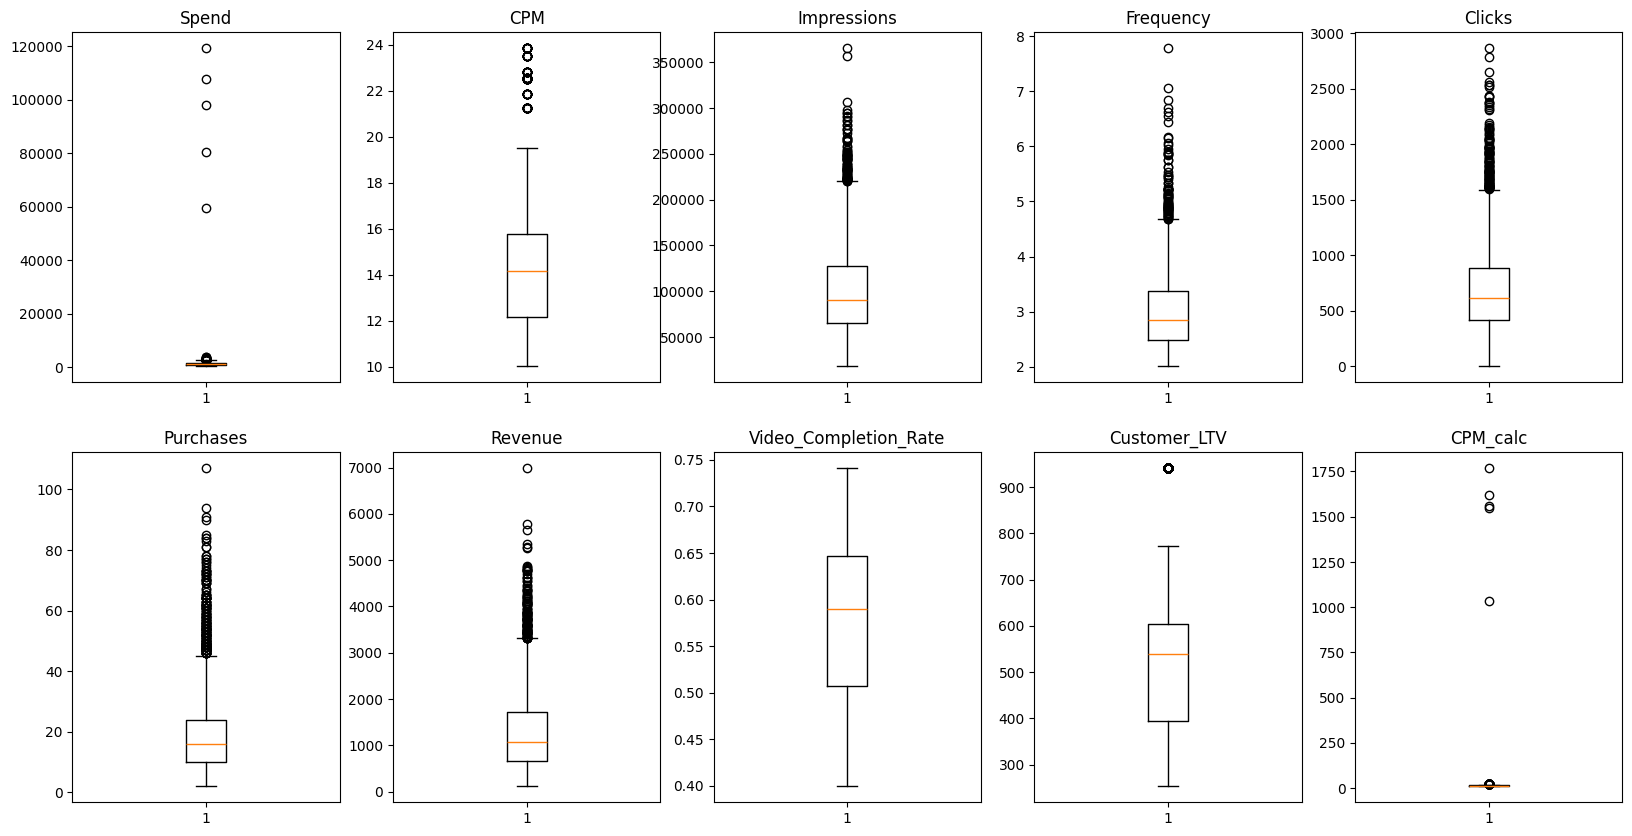

In [372]:
#Code to plot the boxplots

fig, ax = plt.subplots(2, 5, figsize=(20,10))
for i,col in enumerate(numeric_cols):

    row = i // 5
    col_idx = i % 5

    ax[row, col_idx].boxplot(df[col].dropna())
    ax[row, col_idx].set_title(col)

### 1. Spend

**Descriptive Statistics**

- The maximum spend is substantially larger than the 75th percentile, suggesting the presence of unusually large spending values.
- The mean is greater than the median (50th percentile), indicating a **right-skewed** distribution.
- The relatively large standard deviation further suggests considerable variability in campaign spending.




**Distribution**

The distribution appears to be positively skewed, with most campaigns concentrated at lower spending levels and a small number of campaigns exhibiting exceptionally high expenditures.




(array([3.168e+03, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 1.000e+00, 2.000e+00]),
 array([   326.51 ,  12225.359,  24124.208,  36023.057,  47921.906,
         59820.755,  71719.604,  83618.453,  95517.302, 107416.151,
        119315.   ]),
 <BarContainer object of 10 artists>)

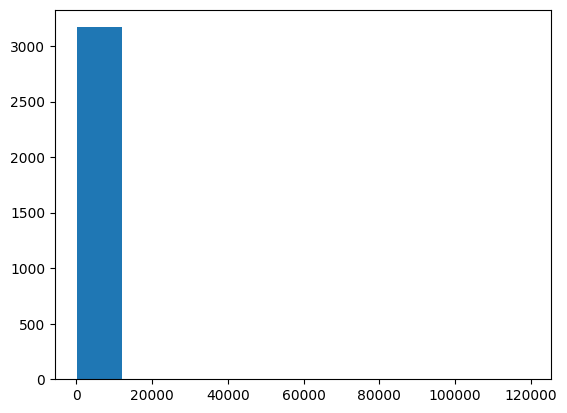

In [373]:
plt.hist(df['Spend'])

**Outliers**

The large gap between the 75th percentile and the maximum value suggests the presence of potential high-end outliers. These observations are further examined using a boxplot.

From the boxplot and histogram, we can see that some severe outliers prevents us to see the whole data distribution. 




{'whiskers': [<matplotlib.lines.Line2D at 0x1f2ac8f11d0>,
 'caps': [<matplotlib.lines.Line2D at 0x1f2ac8f1450>,
 'boxes': [<matplotlib.lines.Line2D at 0x1f2ac8f1090>],
 'medians': [<matplotlib.lines.Line2D at 0x1f2ac8f16d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1f2ac8f1810>],
 'means': []}

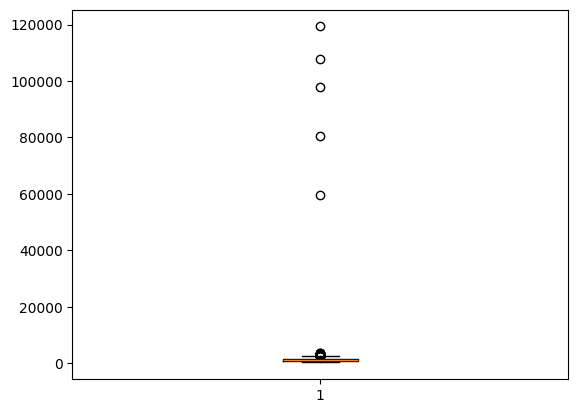

In [374]:
plt.boxplot(df['Spend'])

Now, the question is, what campaign ads are these **5 severe outliers** in terms of ad spend? 


In [375]:
df[outlier_masks["Spend"]].sort_values(by = 'Spend', ascending=False).head(5)

,Date,Platform,Campaign,Region,Spend,CPM,Impressions,Frequency,Clicks,Purchases,Revenue,Product_Category,Target_Audience,Creative_Type,Video_Completion_Rate,Customer_LTV,Is_Competitive_Event,CPM_calc
1286,2024-02-05,TT,TT_Athletes_Video_Protein_001,Northeast,119315.0,10.35,115279,2.97,705,21,1746.21,Protein,Athletes,Video,0.6891,604.8,False,1035.010713
1425,2024-02-09,Google,Google_FitnessEnth_Display_Preworkout_001,South,107742.0,15.58,69131,2.99,798,11,602.20,Preworkout,FitnessEnth,Display,NaN,546.0,False,1558.519333
2892,2024-03-21,Google,Google_Athletes_Search_Protein_001,West,97883.0,16.20,60421,2.35,399,16,1325.27,Protein,Athletes,Search,NaN,940.8,False,1620.016220
2744,2024-03-17,FB,FB_FitnessEnth_Carousel_WeightLoss_001,West,80592.0,15.49,52013,2.36,145,2,125.28,WeightLoss,FitnessEnth,Carousel,NaN,448.5,False,1549.458789
923,2024-01-26,Google,Google_FitnessEnth_Display_Preworkout_001,Midwest,59556.0,17.68,33683,3.44,517,7,414.71,Preworkout,FitnessEnth,Display,NaN,546.0,False,1768.132292


I noticed that in this 5 datapoints, the **CPM do not match the Ad Spend and Impression**. This tells me that there is a possibility that there are more rows with mismatched CPM. So, I checked and found out that only these 5 rows have mismatched CPM, after dropping the rows from earlier(the ones with 0 impression,clicks and purchases).

In [376]:
import numpy as np

df["Calculated_CPM"] = (df["Spend"] / df["Impressions"]) * 1000

# Compare with a tolerance of 0.01
matches = np.isclose(df["Calculated_CPM"], df["CPM"], atol=0.1)

mismatches = df[~matches]

print(f"Number of CPM mismatches: {len(mismatches)}")

mismatches[["Campaign","Spend", "Impressions", "CPM", "Calculated_CPM"]].sort_values(by = 'Spend', ascending=False)

Number of CPM mismatches: 5


,Campaign,Spend,Impressions,CPM,Calculated_CPM
1286,TT_Athletes_Video_Protein_001,119315.0,115279,10.35,1035.010713
1425,Google_FitnessEnth_Display_Preworkout_001,107742.0,69131,15.58,1558.519333
2892,Google_Athletes_Search_Protein_001,97883.0,60421,16.20,1620.016220
2744,FB_FitnessEnth_Carousel_WeightLoss_001,80592.0,52013,15.49,1549.458789
923,Google_FitnessEnth_Display_Preworkout_001,59556.0,33683,17.68,1768.132292


To get a different perspective, we plotted the `Spend` boxplots of the campaigns with severe `Spend` outliers.

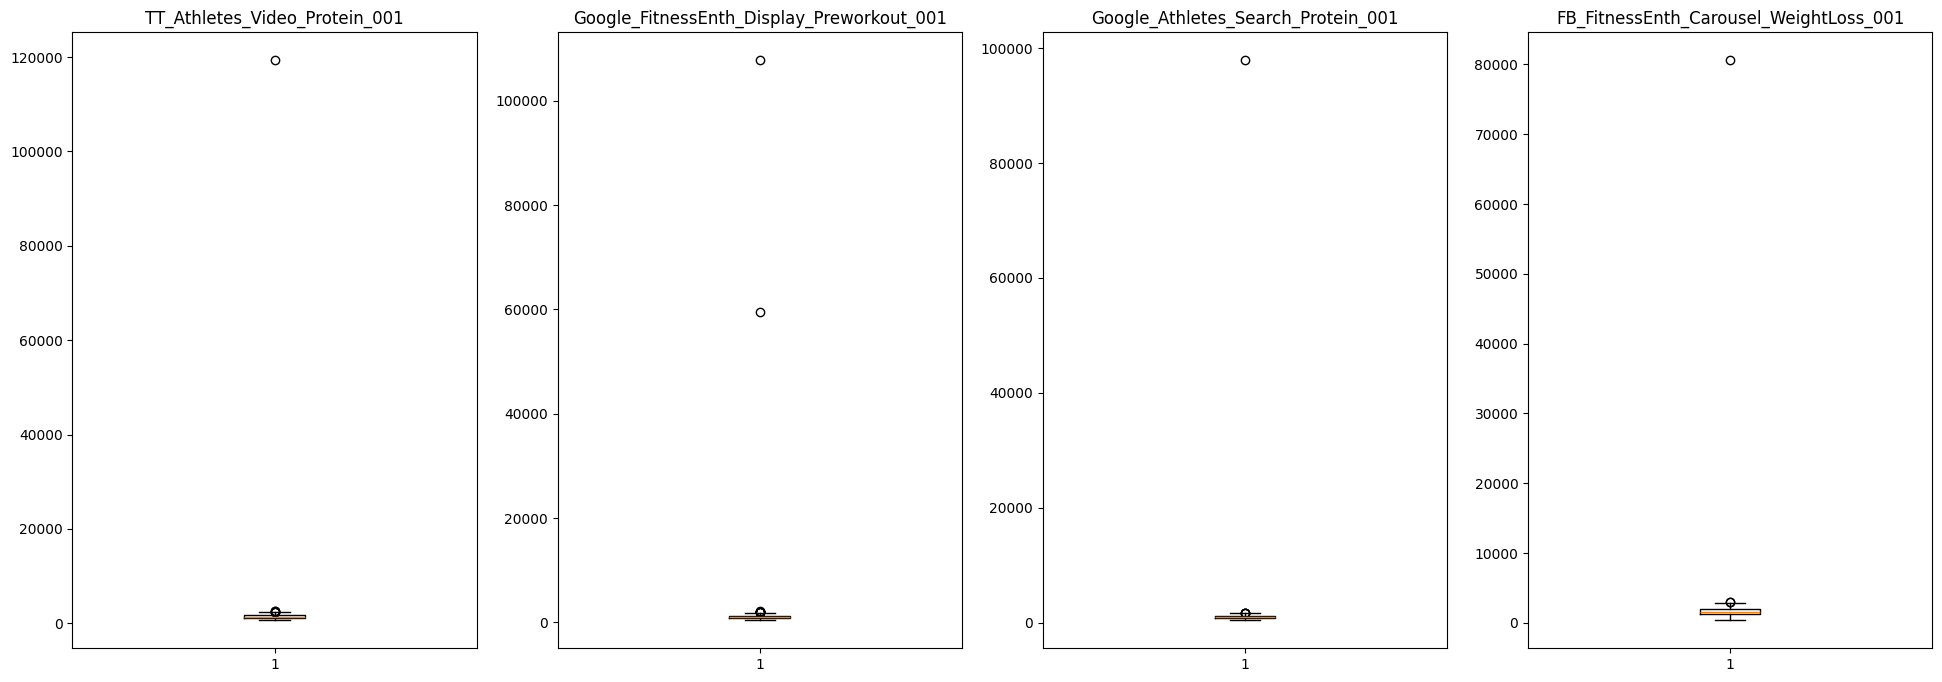

In [377]:
campaigns_with_severe_spend_outliers =['TT_Athletes_Video_Protein_001', 
                                       'Google_FitnessEnth_Display_Preworkout_001', 
                                       'Google_Athletes_Search_Protein_001', 
                                       'FB_FitnessEnth_Carousel_WeightLoss_001', 
                                        ]



fig, ax = plt.subplots(1, 4, figsize=(24,8))
for i,campaign in enumerate(campaigns_with_severe_spend_outliers):

    col_idx = i % 4

    ax[col_idx].boxplot(df[df['Campaign'] == campaign]['Spend'].dropna())
    ax[col_idx].set_title(campaign)


This tells me that indeed, the rows with severe `Spend` outliers are data quality issues and must be addresed.

To summarize, I noticed the following inconsistencies while looking at the datapoint with severe `Spend` outliers.

    1. The reported CPM values(from datapoints with severe `Spend` outliers) were exactly one-hundredth of the values calculated from the corresponding Spend and Impressions.
    2. The calculated CPM values do not match the `Impressions` and `Spend` columns, and this is limited only to the 5 reported rows with severe `Spend` outliers.
    3. Inspection of the affected campaigns showed that the unusually large Spend values occurred only on a single day and were not associated with competitive events.

Since the discrepancy was systematic (a factor of 100) and limited to these five observations, the Spend values were divided by 100 to restore consistency with the reported CPM values.

In [378]:
# Get the indices of the top 5 spend outliers
top5_idx = (
    df.loc[outlier_masks["Spend"]]
      .sort_values(by="Spend", ascending=False)
      .head(5)
      .index
)

# Modify only those rows
df.loc[top5_idx, "Spend"] /= 100

# Display them
df.loc[top5_idx]

,Date,Platform,Campaign,Region,Spend,CPM,Impressions,Frequency,Clicks,Purchases,Revenue,Product_Category,Target_Audience,Creative_Type,Video_Completion_Rate,Customer_LTV,Is_Competitive_Event,CPM_calc,Calculated_CPM
1286,2024-02-05,TT,TT_Athletes_Video_Protein_001,Northeast,1193.15,10.35,115279,2.97,705,21,1746.21,Protein,Athletes,Video,0.6891,604.8,False,1035.010713,1035.010713
1425,2024-02-09,Google,Google_FitnessEnth_Display_Preworkout_001,South,1077.42,15.58,69131,2.99,798,11,602.20,Preworkout,FitnessEnth,Display,NaN,546.0,False,1558.519333,1558.519333
2892,2024-03-21,Google,Google_Athletes_Search_Protein_001,West,978.83,16.20,60421,2.35,399,16,1325.27,Protein,Athletes,Search,NaN,940.8,False,1620.016220,1620.016220
2744,2024-03-17,FB,FB_FitnessEnth_Carousel_WeightLoss_001,West,805.92,15.49,52013,2.36,145,2,125.28,WeightLoss,FitnessEnth,Carousel,NaN,448.5,False,1549.458789,1549.458789
923,2024-01-26,Google,Google_FitnessEnth_Display_Preworkout_001,Midwest,595.56,17.68,33683,3.44,517,7,414.71,Preworkout,FitnessEnth,Display,NaN,546.0,False,1768.132292,1768.132292


We have now addressed the `Spend` outliers. Now, let's try to plot the boxplots for `Spend` of each campaign ads

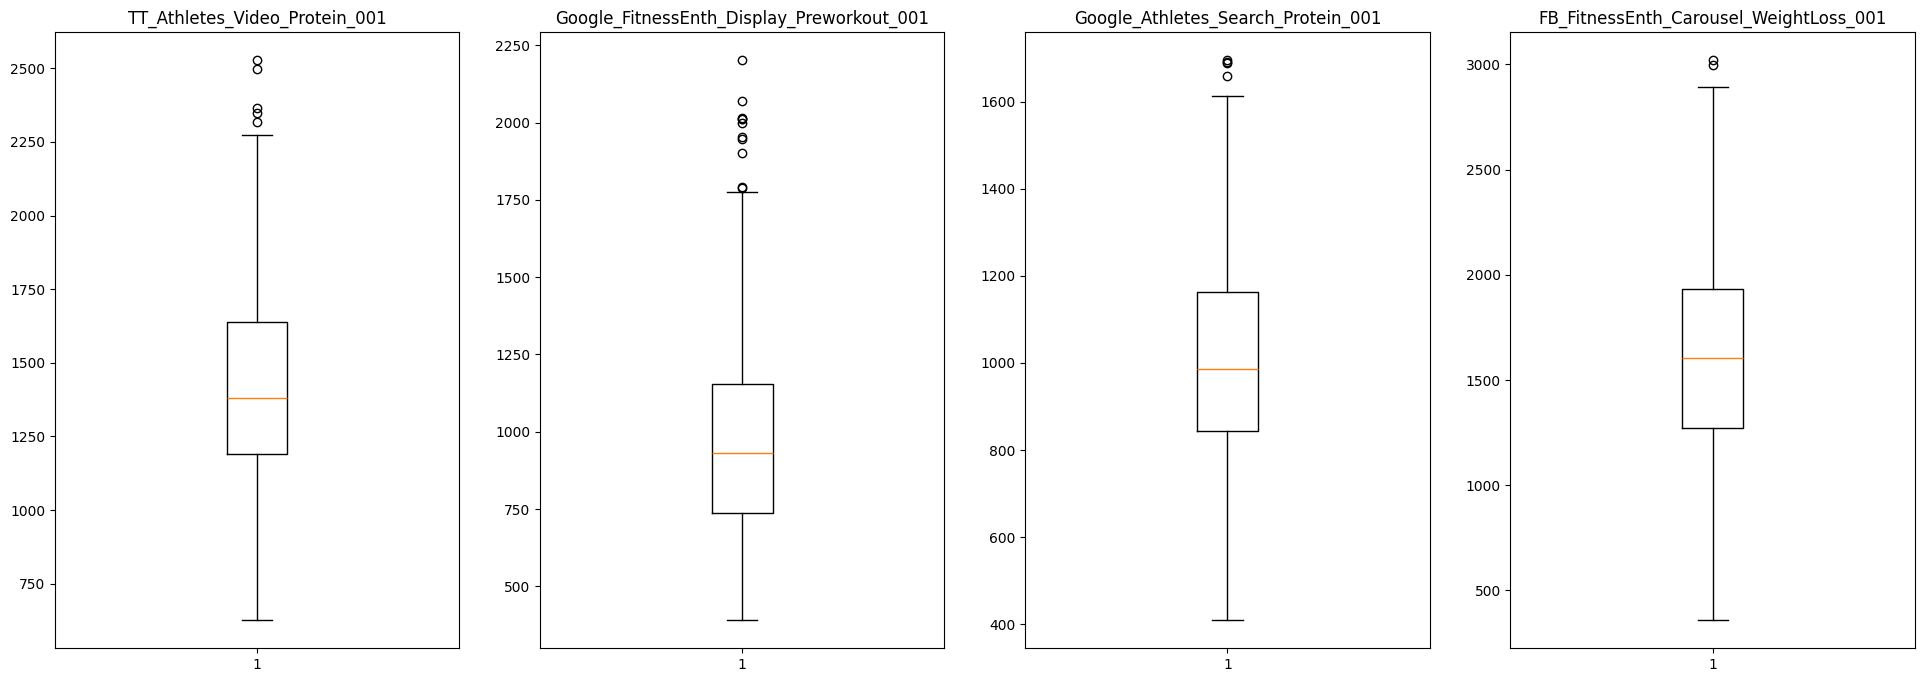

In [379]:
campaigns_with_severe_spend_outliers =['TT_Athletes_Video_Protein_001', 
                                       'Google_FitnessEnth_Display_Preworkout_001', 
                                       'Google_Athletes_Search_Protein_001', 
                                       'FB_FitnessEnth_Carousel_WeightLoss_001', 
                                        ]



fig, ax = plt.subplots(1, 4, figsize=(24,8))
for i,campaign in enumerate(campaigns_with_severe_spend_outliers):

    col_idx = i % 4

    ax[col_idx].boxplot(df[df['Campaign'] == campaign]['Spend'].dropna())
    ax[col_idx].set_title(campaign)


Looks good to me!

In [380]:
df['Spend'].sum()

np.float64(4310680.390000001)

I confirmed if there are more CPM mismatches.

In [381]:
import numpy as np

df["Calculated_CPM"] = (df["Spend"] / df["Impressions"]) * 1000

# Compare with a tolerance of 0.01
matches = np.isclose(df["Calculated_CPM"], df["CPM"], atol=0.1)

mismatches = df[~matches]

print(f"Number of CPM mismatches: {len(mismatches)}")

mismatches[["Spend", "Impressions", "CPM", "Calculated_CPM"]]

Number of CPM mismatches: 0


,Spend,Impressions,CPM,Calculated_CPM


## Campaign_ID

I noticed that the `Campaign` column contains redundant information from `Platform`, `Target_Audience`, `Creative_type`, and `Product_Categories` except for the last number which looks like an identifier(001, 002). 

I think adding a new column for this, which we will call `campaign_id`, will be important later when we want to compare exactly the same campaign ads(same prod_cat, target_aud, creative_type and campaign_id) across different platforms.

In [382]:
df['campaign_id'] = df["Campaign"].str.extract(r'(\d{3})$')

df

,Date,Platform,Campaign,Region,Spend,CPM,Impressions,Frequency,Clicks,Purchases,Revenue,Product_Category,Target_Audience,Creative_Type,Video_Completion_Rate,Customer_LTV,Is_Competitive_Event,CPM_calc,Calculated_CPM,campaign_id
0,2024-01-01,FB,FB_Athletes_Video_Protein_001,West,1187.29,18.00,65960,2.75,527,15,1216.74,Protein,Athletes,Video,0.4860,772.80,True,18.000152,18.000152,001
1,2024-01-01,FB,FB_Athletes_Video_Protein_001,South,1081.89,18.00,60105,2.51,512,12,868.16,Protein,Athletes,Video,0.4860,772.80,True,18.000000,18.000000,001
2,2024-01-01,FB,FB_Athletes_Video_Protein_001,Northeast,648.47,18.00,36025,2.52,344,9,694.68,Protein,Athletes,Video,0.4860,772.80,True,18.000555,18.000555,001
3,2024-01-01,FB,FB_Athletes_Video_Protein_001,Midwest,463.38,18.00,25743,2.49,272,6,482.66,Protein,Athletes,Video,0.4860,772.80,True,18.000233,18.000233,001
4,2024-01-01,FB,FB_Athletes_Image_Preworkout_002,West,800.59,18.00,44477,3.10,418,14,852.22,Preworkout,Athletes,Image,NaN,538.20,True,18.000090,18.000090,002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3235,2024-03-30,TT,TT_FitnessEnth_Video_Preworkout_001,Midwest,1210.98,15.03,80580,2.25,357,8,475.93,Preworkout,FitnessEnth,Video,NaN,351.00,False,15.028295,15.028295,001
3236,2024-03-30,TT,TT_WeightLoss_Video_Diet_001,West,1393.13,15.03,92701,2.89,334,8,491.48,Diet,WeightLoss,Video,0.5076,252.72,False,15.028209,15.028209,001
3237,2024-03-30,TT,TT_WeightLoss_Video_Diet_001,South,1879.82,15.03,125086,2.42,517,12,665.84,Diet,WeightLoss,Video,0.5076,252.72,False,15.028221,15.028221,001
3238,2024-03-30,TT,TT_WeightLoss_Video_Diet_001,Northeast,2312.32,15.03,153865,3.67,614,18,1067.11,Diet,WeightLoss,Video,0.5076,252.72,False,15.028239,15.028239,001


In [383]:
df.describe()

,Date,Spend,CPM,Impressions,Frequency,Clicks,Purchases,Revenue,Video_Completion_Rate,Customer_LTV,CPM_calc,Calculated_CPM
count,3173,3173.000000,3173.000000,3173.000000,3173.000000,3173.000000,3173.000000,3173.000000,1207.000000,3173.000000,3173.000000,3173.000000
mean,2024-02-14 07:44:43.265048832,1358.550391,14.208991,101623.601954,3.010113,699.414434,19.584620,1302.632105,0.575756,537.471926,16.559322,14.209551
min,2024-01-01 00:00:00,326.510000,10.010000,18026.000000,2.010000,0.000000,2.000000,113.600000,0.399500,252.720000,10.010008,10.010008
25%,2024-01-23 00:00:00,985.480000,12.160000,64955.000000,2.490000,417.000000,10.000000,651.680000,0.507600,393.120000,12.155630,12.155619
50%,2024-02-14 00:00:00,1268.070000,14.170000,90221.000000,2.850000,620.000000,16.000000,1071.120000,0.590300,538.200000,14.172778,14.172730
75%,2024-03-08 00:00:00,1661.990000,15.750000,127118.000000,3.370000,887.000000,24.000000,1714.640000,0.646600,604.800000,15.765051,15.750196
max,2024-03-30 00:00:00,3709.070000,23.850000,365425.000000,7.780000,2866.000000,107.000000,6987.780000,0.741000,940.800000,1768.132292,23.850600
std,NaN,513.259413,2.984366,49037.349182,0.701217,408.520788,13.716419,883.692117,0.092228,201.976923,60.079497,2.984601


## Campaign_ID

I noticed that the `Campaign` column contains redundant information from `Platform`, `Target_Audience`, `Creative_type`, and `Product_Categories` except for the last number which looks like an identifier(001, 002). 

I think adding a new column for this, which we will call `campaign_id`, will be important later when we want to compare exactly the same campaign ads(same prod_cat, target_aud, creative_type and campaign_id) across different platforms.

In [384]:
df['campaign_id'] = df["Campaign"].str.extract(r'(\d{3})$')

df

,Date,Platform,Campaign,Region,Spend,CPM,Impressions,Frequency,Clicks,Purchases,Revenue,Product_Category,Target_Audience,Creative_Type,Video_Completion_Rate,Customer_LTV,Is_Competitive_Event,CPM_calc,Calculated_CPM,campaign_id
0,2024-01-01,FB,FB_Athletes_Video_Protein_001,West,1187.29,18.00,65960,2.75,527,15,1216.74,Protein,Athletes,Video,0.4860,772.80,True,18.000152,18.000152,001
1,2024-01-01,FB,FB_Athletes_Video_Protein_001,South,1081.89,18.00,60105,2.51,512,12,868.16,Protein,Athletes,Video,0.4860,772.80,True,18.000000,18.000000,001
2,2024-01-01,FB,FB_Athletes_Video_Protein_001,Northeast,648.47,18.00,36025,2.52,344,9,694.68,Protein,Athletes,Video,0.4860,772.80,True,18.000555,18.000555,001
3,2024-01-01,FB,FB_Athletes_Video_Protein_001,Midwest,463.38,18.00,25743,2.49,272,6,482.66,Protein,Athletes,Video,0.4860,772.80,True,18.000233,18.000233,001
4,2024-01-01,FB,FB_Athletes_Image_Preworkout_002,West,800.59,18.00,44477,3.10,418,14,852.22,Preworkout,Athletes,Image,NaN,538.20,True,18.000090,18.000090,002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3235,2024-03-30,TT,TT_FitnessEnth_Video_Preworkout_001,Midwest,1210.98,15.03,80580,2.25,357,8,475.93,Preworkout,FitnessEnth,Video,NaN,351.00,False,15.028295,15.028295,001
3236,2024-03-30,TT,TT_WeightLoss_Video_Diet_001,West,1393.13,15.03,92701,2.89,334,8,491.48,Diet,WeightLoss,Video,0.5076,252.72,False,15.028209,15.028209,001
3237,2024-03-30,TT,TT_WeightLoss_Video_Diet_001,South,1879.82,15.03,125086,2.42,517,12,665.84,Diet,WeightLoss,Video,0.5076,252.72,False,15.028221,15.028221,001
3238,2024-03-30,TT,TT_WeightLoss_Video_Diet_001,Northeast,2312.32,15.03,153865,3.67,614,18,1067.11,Diet,WeightLoss,Video,0.5076,252.72,False,15.028239,15.028239,001


In [385]:
df.to_excel("../data/marketing_data_cleaned.xlsx", index=False)